#PROJECT SUSPENSO ML MODEL
##### In this model will predit precious camber angle.

### Importing Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

### Import Dataset

In [ ]:
Suspensos_df = pd.read_csv("SuspensionData.csv")

In [ ]:
Suspensos_df.head(10)

,Alpha_L1,Alpha_L2,Alpha_R1,Alpha_R2,CamberL1,CamberR1,Fx_Air,Fx_L1,Fx_L2,Fx_R1,...,MuX_L2,MuX_R1,MuX_R2,MuY_L1,MuY_L2,MuY_R1,MuY_R2,Steer_SW,Toe_L1,Toe_R1
0,-0.098183,0.047403,0.046357,-0.042254,0.168666,0.164946,-295.280769,-59.256591,1482.854668,-60.057923,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.959203,0.0,0.0
1,-0.106088,0.045124,0.038589,-0.044524,0.168466,0.165429,-296.315728,-59.056336,1482.723051,-60.183461,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.234368,0.0,0.0
2,-0.112073,0.041449,0.032740,-0.048190,0.168487,0.165686,-297.351892,-58.925987,1482.590093,-60.288152,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.412508,0.0,0.0
3,-0.115398,0.036503,0.029593,-0.053125,0.168719,0.165731,-298.389232,-58.885113,1482.433128,-60.359820,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.487293,0.0,0.0
4,-0.116613,0.030632,0.028442,-0.058985,0.169121,0.165599,-299.427727,-58.937207,1482.224666,-60.350283,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.477197,0.0,0.0
5,-0.117260,0.024319,0.027974,-0.065285,0.169541,0.165453,-300.467382,-59.045066,1481.946580,-60.246163,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.403997,0.0,0.0
6,-0.117341,0.018037,0.028013,-0.071554,0.169900,0.165361,-301.508199,-59.176185,1481.593094,-60.103881,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.278424,0.0,0.0
7,-0.116989,0.012179,0.028482,-0.077399,0.170210,0.165321,-302.550172,-59.314101,1481.176743,-59.949973,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.108739,0.0,0.0
8,-0.115948,0.007053,0.029641,-0.082510,0.170496,0.165305,-303.593289,-59.449592,1480.723488,-59.803560,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.903156,0.0,0.0
9,-0.114118,0.002906,0.031529,-0.086644,0.170803,0.165270,-304.637534,-59.581413,1480.258997,-59.663216,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.674404,0.0,0.0


In [ ]:
Suspensos_df.describe()

,Alpha_L1,Alpha_L2,Alpha_R1,Alpha_R2,CamberL1,CamberR1,Fx_Air,Fx_L1,Fx_L2,Fx_R1,...,MuX_L2,MuX_R1,MuX_R2,MuY_L1,MuY_L2,MuY_R1,MuY_R2,Steer_SW,Toe_L1,Toe_R1
count,51576.000000,51576.000000,51576.000000,51576.000000,51576.000000,51576.000000,51576.000000,51576.000000,51576.000000,51576.000000,...,51576.00000,51576.000000,51576.000000,51576.000000,51576.00000,51576.000000,51576.000000,51576.000000,51576.000000,51576.000000
mean,0.331195,0.644919,1.341021,0.715130,-1.113485,-1.698060,-177.569881,-494.877966,716.385677,-461.451142,...,1.01206,1.012872,1.012968,1.011679,1.01206,1.012872,1.012968,-2.278810,0.137091,-0.832525
std,4.060683,3.108413,4.210428,3.125453,2.014138,2.488768,85.121943,960.509848,1221.793493,880.684612,...,0.03464,0.036991,0.036011,0.035372,0.03464,0.036991,0.036011,63.491007,2.426986,2.631882
min,-88.294297,-89.695365,-89.838310,-88.837699,-4.721941,-8.239684,-495.495520,-4643.279203,-3076.481246,-4658.600591,...,0.87500,0.750000,0.750000,0.750000,0.87500,0.750000,0.750000,-720.000000,-3.600000,-4.700000
25%,-1.623480,-1.034455,-1.196450,-1.098942,-3.221793,-2.857261,-224.253439,-302.611868,-179.492063,-302.205129,...,1.00000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,-43.560753,-2.000000,-2.300000
50%,1.019176,0.765221,1.216071,0.689723,-0.853438,-1.625912,-153.825952,-68.989084,989.154036,-67.890867,...,1.00000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,-0.429226,0.000000,-1.000000
75%,2.558325,2.361309,3.432075,2.461413,0.488941,-0.748452,-115.149275,-49.880282,1692.242252,-47.880588,...,1.00000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,37.310880,2.800000,0.000000
max,44.442573,26.164375,60.230065,27.178139,4.132980,5.455895,72.891149,1482.098959,4259.458250,1088.587461,...,1.10000,1.100000,1.100000,1.100000,1.10000,1.100000,1.100000,720.000000,4.300000,6.000000


In [ ]:
Suspensos_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1337 entries, 0 to 1336
Data columns (total 31 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Time       1337 non-null   float64
 1    Alpha_L1  1337 non-null   float64
 2    Alpha_L2  1337 non-null   float64
 3    Alpha_R1  1337 non-null   float64
 4    Alpha_R2  1337 non-null   float64
 5    CamberL1  1337 non-null   float64
 6    CamberR1  1337 non-null   float64
 7    Fx_Air    1337 non-null   float64
 8    Fx_L1     1337 non-null   float64
 9    Fx_L2     1337 non-null   float64
 10   Fx_R1     1337 non-null   float64
 11   Fx_R2     1337 non-null   float64
 12   Fy_Air    1337 non-null   float64
 13   Fy_L1     1337 non-null   float64
 14   Fy_L2     1337 non-null   float64
 15   Fy_R1     1337 non-null   float64
 16   Fy_R2     1337 non-null   float64
 17   Fz_Air    1337 non-null   float64
 18   Fz_L1     1337 non-null   float64
 19   Fz_L2     1337 non-null   float64
 20   Fz_R1  

### Visualize Dataset

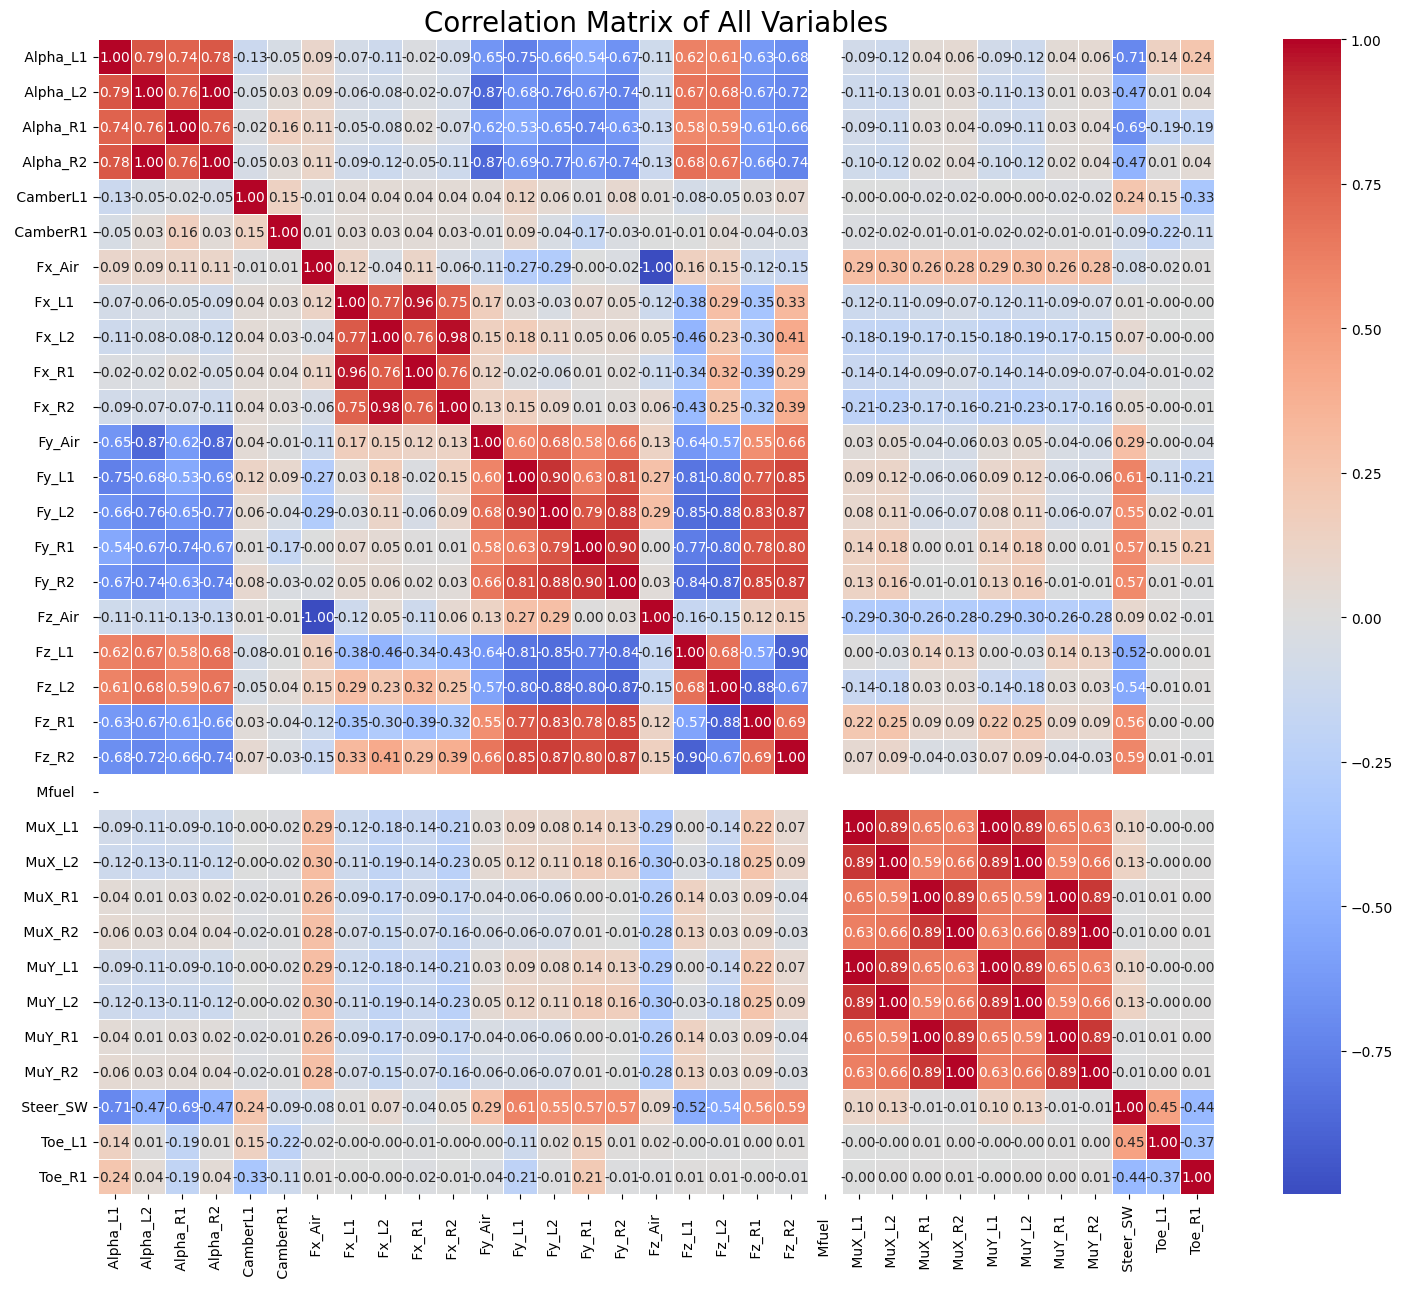

In [ ]:
plt.figure(figsize=(18, 15))
# Calculate correlation matrix for all remaining columns
correlation_matrix = Suspensos_df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of All Variables', fontsize=20)
plt.show()

ValueError: Could not interpret value `Steer_SW` for `y`. An entry with this name does not appear in `data`.

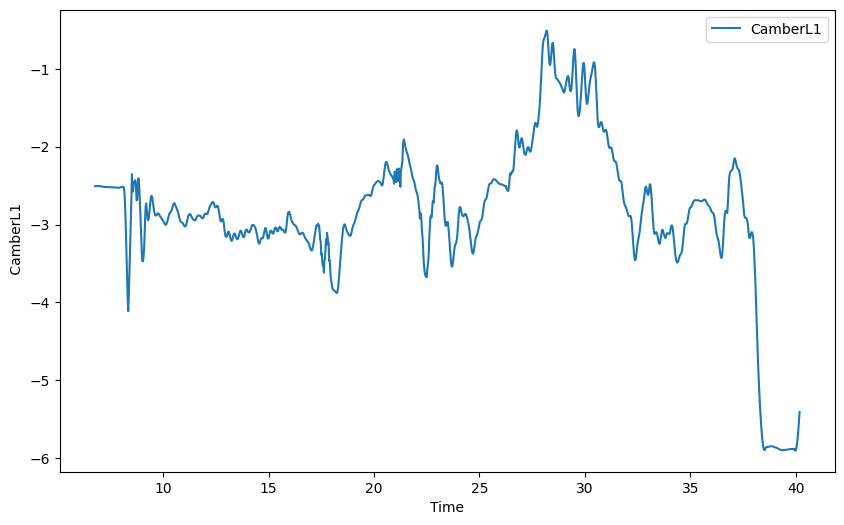

In [ ]:
plt.figure(figsize=(10, 6))
sns.lineplot(data=Suspensos_df, x='Time', y=' CamberL1', label='CamberL1')
sns.lineplot(data=Suspensos_df, x='Time', y='Steer_SW', label='Steer_SW')
plt.title('CamberL1 and Steer_SW over Time')
plt.xlabel('Time')
plt.ylabel('Value')
plt.legend()
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# Import Axes3D for 3D plotting
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns

# Ensure plots are displayed inline in Jupyter notebooks
%matplotlib inline

print("--- Starting 3D Scatter Plot Generation ---")

# --- 1. Load the dataset ---
# Make sure 'SuspensionData.csv' is in the same directory as your notebook,
# or provide the full path to the file.
try:
    df = pd.read_csv("SuspensionData.csv")
    print("\nDataset loaded successfully!")
except FileNotFoundError:
    print("Error: 'SuspensionData.csv' not found. Please ensure the file is in the correct directory.")
    exit() # Exit if the file isn't found to prevent further errors

# --- 2. Define the columns for the 3D plot ---
x_col = ' Steer_SW'
y_col = ' Alpha_R1' # Chosen as the third dimension
z_col = ' CamberR1'

# --- 3. Create a new figure and an Axes3D object ---
plt.figure(figsize=(10, 8)) # Adjust figure size as needed for better visualization
ax = plt.axes(projection='3d') # Create a 3D subplot

# --- 4. Plot the 3D scatter points ---
# Use the data from your DataFrame
# Ensure column names are correct, handling potential leading/trailing spaces from CSV headers
ax.scatter(df[x_col], df[y_col], df[z_col], c='blue', marker='o', alpha=0.6)

# --- 5. Set labels and title for the 3D plot ---
ax.set_xlabel(f'{x_col} (Steering Wheel Angle)')
ax.set_ylabel(f'{y_col} (Slip Angle Front Right Wheel)')
ax.set_zlabel(f'{z_col} (Camber Angle Front Right Wheel)')
ax.set_title(f'3D Relationship between {x_col}, {y_col}, and {z_col}', fontsize=16)

# --- 6. Show the plot ---
plt.show()

print("\n--- 3D Scatter Plot Generation Complete ---")


In [ ]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
LabelEncoder_y = LabelEncoder()
Suspensos_df[' Alpha_L1'] = LabelEncoder_y.fit_transform(Suspensos_df[' Alpha_L1'])

Step 1: Loading and Preprocessing Data...
SuspensionData.csv loaded successfully.

Cleaned DataFrame columns:
Index(['Alpha_L1', 'Alpha_L2', 'Alpha_R1', 'Alpha_R2', 'CamberL1', 'CamberR1',
       'Fx_L1', 'Fx_L2', 'Fx_R1', 'Fx_R2', 'Fy_L1', 'Fy_L2', 'Fy_R1', 'Fy_R2',
       'Fz_L1', 'Fz_L2', 'Fz_R1', 'Fz_R2', 'MuX_L1', 'MuX_L2', 'MuX_R1',
       'MuX_R2', 'MuY_L1', 'MuY_L2', 'MuY_R1', 'MuY_R2', 'Steer_SW', 'Toe_L1',
       'Toe_R1'],
      dtype='object')

Shape of Features (X): (51576, 25)
Shape of Targets (y): (51576, 4)
------------------------------

Step 2: Splitting and Scaling Data...
Data has been split and scaled.
X_train_scaled shape: (41260, 25)
X_test_scaled shape: (10316, 25)
------------------------------

Step 3: Building the Neural Network...


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Hidden_Layer_1 (Dense)          │ (None, 64)             │         1,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden_Layer_2 (Dense)          │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden_Layer_3 (Dense)          │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output_Layer (Dense)            │ (None, 4)              │            68 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,340 (16.95 KB)

 Trainable params: 4,340 (16.95 KB)

 Non-trainable params: 0 (0.00 B)

------------------------------

Step 4: Training the Model...
Epoch 1/100
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 3.5576 - mean_absolute_error: 1.3919 - val_loss: 1.5774 - val_mean_absolute_error: 0.8872
Epoch 2/100
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 1.3913 - mean_absolute_error: 0.8439 - val_loss: 1.0644 - val_mean_absolute_error: 0.7386
Epoch 3/100
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.9947 - mean_absolute_error: 0.7113 - val_loss: 0.8850 - val_mean_absolute_error: 0.6593
Epoch 4/100
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.8160 - mean_absolute_error: 0.6318 - val_loss: 0.7200 - val_mean_absolute_error: 0.5915
Epoch 5/100
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.6627 - mean_absolute_error: 0.5641 - val_loss: 0.6047 - val_mean_absolute_error: 0.5321
Epoch 6/100
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.5736 - mean_absolute_error: 0.5193 - val_loss: 0.5167 - val_mean_absolute_error: 0.4825
Epoch 7/100
1032/103

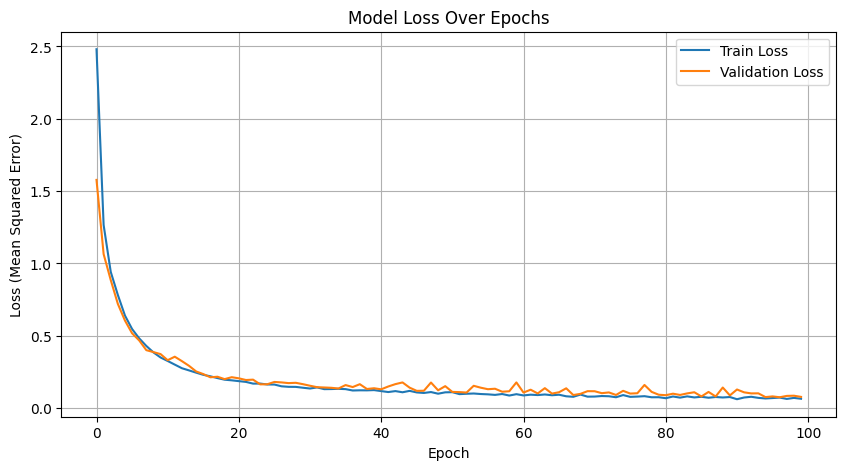

Loss plot saved as model_loss_plot.png
------------------------------

Step 6: Evaluating Model Performance on Unseen Test Data...
  - Test Loss (MSE): 0.0845
  - Test Mean Absolute Error (MAE): 0.1353
------------------------------

Step 7: Making a Prediction on a Sample...

Sample Input Data:
       Alpha_L1  Alpha_L2  Alpha_R1  Alpha_R2       Fx_L1       Fx_L2      Fx_R1       Fx_R2       Fy_L1      Fy_L2        Fy_R1       Fy_R2        Fz_L1        Fz_L2        Fz_R1        Fz_R2  MuX_L1  MuX_L2  MuX_R1  MuX_R2  MuY_L1  MuY_L2  MuY_R1  MuY_R2  Steer_SW
32989 -0.829744  0.310571  1.794479  0.229187 -133.680622  715.657082 -119.99252  730.012385  717.005477 -293.17464 -1299.789985 -186.913011  2627.008882  3086.065017  2350.066724  2800.146773     1.0     1.0     1.0     1.0     1.0     1.0     1.0     1.0  9.568942
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step

--- PREDICTION RESULTS ---

✅ Predicted Angles:
  - Predicted CamberL1: -1.1632
  - Predicted CamberR1: -1.5757
  - Predicted Toe

In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# --- 1. Load and Preprocess Data ---
print("Step 1: Loading and Preprocessing Data...")
try:
    df = pd.read_csv('SuspensionData.csv')
    print("SuspensionData.csv loaded successfully.")
except FileNotFoundError:
    print("Error: SuspensionData.csv not found. Please ensure it's in the correct directory.")
    exit() # Exit if the essential data file is not found

# Clean column names by stripping leading/trailing whitespace
df.columns = df.columns.str.strip()

# Drop the columns specified as unnecessary
# Also dropping 'Mfuel' as it likely contains no predictive information
columns_to_drop = ['Fx_Air', 'Fy_Air', 'Fz_Air', 'Mfuel']
df_cleaned = df.drop(columns=columns_to_drop)

print("\nCleaned DataFrame columns:")
print(df_cleaned.columns)

# Define features (X) and the four targets (y)
features = df_cleaned.drop(['CamberL1', 'CamberR1', 'Toe_L1', 'Toe_R1'], axis=1)
targets = df_cleaned[['CamberL1', 'CamberR1', 'Toe_L1', 'Toe_R1']]

print("\nShape of Features (X):", features.shape)
print("Shape of Targets (y):", targets.shape)
print("-" * 30)


# --- 2. Split and Scale Data ---
print("\nStep 2: Splitting and Scaling Data...")
# Split the data into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(features, targets, test_size=0.2, random_state=42)

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit the scaler ONLY on the training data and transform both sets
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data has been split and scaled.")
print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)
print("-" * 30)


# --- 3. Build the Neural Network ---
print("\nStep 3: Building the Neural Network...")
model = tf.keras.Sequential([
    tf.keras.layers.InputLayer(input_shape=(X_train_scaled.shape[1],), name="Input_Layer"),
    tf.keras.layers.Dense(64, activation='relu', name="Hidden_Layer_1"),
    tf.keras.layers.Dense(32, activation='relu', name="Hidden_Layer_2"),
    tf.keras.layers.Dense(16, activation='relu', name="Hidden_Layer_3"),
    tf.keras.layers.Dense(4, activation='linear', name="Output_Layer") # Linear activation for regression
])

# Compile the model
model.compile(optimizer='adam',
              loss='mean_squared_error',
              metrics=['mean_absolute_error'])

# Display the model's architecture
model.summary()
print("-" * 30)


# --- 4. Train the Model ---
print("\nStep 4: Training the Model...")
history = model.fit(
    X_train_scaled, y_train,
    epochs=100,
    validation_split=0.2,
    batch_size=32,
    verbose=1
)
print("Model training complete.")
print("-" * 30)


# --- 5. Visualize Training History ---
print("\nStep 5: Visualizing Model Loss...")
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss Over Epochs')
plt.ylabel('Loss (Mean Squared Error)')
plt.xlabel('Epoch')
plt.legend(loc='upper right')
plt.grid(True)
plt.savefig("model_loss_plot.png") # Saves the plot as an image
plt.show()
print("Loss plot saved as model_loss_plot.png")
print("-" * 30)


# --- 6. Evaluate Model Performance ---
print("\nStep 6: Evaluating Model Performance on Unseen Test Data...")
test_loss, test_mae = model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"  - Test Loss (MSE): {test_loss:.4f}")
print(f"  - Test Mean Absolute Error (MAE): {test_mae:.4f}")
print("-" * 30)


# --- 7. Make Predictions on New Data ---
print("\nStep 7: Making a Prediction on a Sample...")
# Get a single sample from the test set to predict
sample_input = X_test.iloc[[0]]
sample_actual_output = y_test.iloc[[0]]

print("\nSample Input Data:")
print(sample_input.to_string())

# IMPORTANT: Scale the new data using the same scaler from training
sample_input_scaled = scaler.transform(sample_input)

# Use the trained model to predict the output
predicted_output = model.predict(sample_input_scaled)

# Display the results clearly
print("\n--- PREDICTION RESULTS ---")
print("\n✅ Predicted Angles:")
print(f"  - Predicted CamberL1: {predicted_output[0][0]:.4f}")
print(f"  - Predicted CamberR1: {predicted_output[0][1]:.4f}")
print(f"  - Predicted Toe_L1:   {predicted_output[0][2]:.4f}")
print(f"  - Predicted Toe_R1:   {predicted_output[0][3]:.4f}")

print("\n🎯 Actual Angles (for comparison):")
print(sample_actual_output.to_string(index=False))
print("-" * 30)